<a href="https://colab.research.google.com/github/comparativechrono/Comparative-birthograms-reveal-country-specific-rephasing-of-human-birth-seasonality/blob/main/Photoperiod%20chow%20tests%20from%20Hearn%20and%20Whitmore%202025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adapted analysis for French and German birth and photoperiod dataset

This notebook is adapted to a CSV with four columns: `year`, `month`, `birth rate`, and `photoperiod`. It reconstructs a monthly date index and reproduces the original Hearn and Whitmore analyses using the variables that are still present.

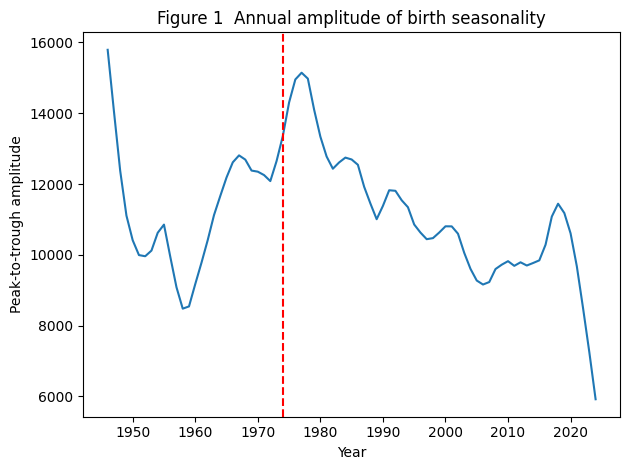

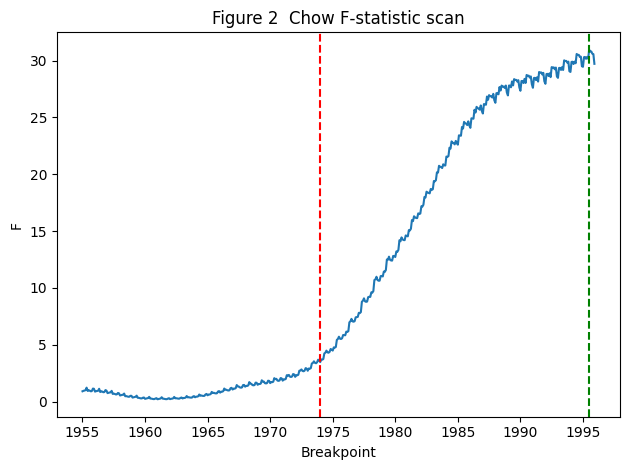

Parsed data range: 1946-01-01 to 2024-12-01
Rows: 948
Best breakpoint: 1995-07-01
Max F: 30.943212

Top Chow candidates:
                     F             p
1995-07-01  30.943212  9.625634e-14
1995-08-01  30.800589  1.101341e-13
1995-09-01  30.795204  1.106892e-13
1995-10-01  30.600227  1.328937e-13
1994-07-01  30.575035  1.361133e-13


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from scipy.stats import f

# 1 Load data -------------------------------------------------------------
def load_environmental_csv(path='french_photoperiod_data.csv'):
    # First try reading with headers
    trial = pd.read_csv(path)
    normalized = {str(c).strip().lower().replace('_', ' '): c for c in trial.columns}
    required = ['year', 'month', 'birth rate', 'photoperiod']

    if all(col in normalized for col in required):
        df = trial.rename(columns={
            normalized['year']: 'year',
            normalized['month']: 'month',
            normalized['birth rate']: 'birth_rate',
            normalized['photoperiod']: 'photoperiod',
        }).copy()
    else:
        # Fall back to a 4-column file with no header row
        df = pd.read_csv(
            path,
            header=None,
            names=['year', 'month', 'birth_rate', 'photoperiod']
        ).copy()

    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df['birth_rate'] = pd.to_numeric(df['birth_rate'], errors='coerce')
    df['photoperiod'] = pd.to_numeric(df['photoperiod'], errors='coerce')
    df['month'] = df['month'].astype(str).str.strip()

    # Parse full month names first, then abbreviations if needed
    month_full = pd.to_datetime(df['month'], format='%B', errors='coerce').dt.month
    month_abbr = pd.to_datetime(df['month'], format='%b', errors='coerce').dt.month
    df['month_num'] = month_full.fillna(month_abbr)

    bad_rows = df[df[['year', 'month_num', 'birth_rate', 'photoperiod']].isna().any(axis=1)]
    if not bad_rows.empty:
        raise ValueError(
            "Some rows could not be parsed in the new dataset format.\n"
            f"Problem rows:\n{bad_rows.head()}"
        )

    df['Date'] = pd.to_datetime(
        dict(year=df['year'].astype(int), month=df['month_num'].astype(int), day=1)
    )

    df = (
        df[['Date', 'birth_rate', 'photoperiod']]
        .rename(columns={'birth_rate': 'BR'})
        .set_index('Date')
        .sort_index()
    )
    return df

df = load_environmental_csv('french_photoperiod_data.csv')

# 2 STL decomposition -----------------------------------------------------
period = 12
seasonals = {
    c: STL(df[c], period=period, robust=True).fit().seasonal
    for c in ['BR', 'photoperiod']
}
dfs = pd.DataFrame(seasonals).dropna()

# Figure 1 – birth-season amplitude --------------------------------------
amp = dfs['BR'].groupby(dfs.index.year).agg(lambda x: x.max() - x.min())
plt.figure(facecolor='white')
plt.plot(amp.index, amp.values)
plt.axvline(1974, ls='--', c='r')
plt.title('Figure 1  Annual amplitude of birth seasonality')
plt.xlabel('Year')
plt.ylabel('Peak-to-trough amplitude')
plt.tight_layout()
plt.savefig('figure_1_birth_seasonality_amplitude.png', dpi=300, bbox_inches='tight')
plt.show()

# 3 Static regression set-up ---------------------------------------------
y = dfs['BR']
X = sm.add_constant(dfs[['photoperiod']])

# Figure 2 – Chow scan ----------------------------------------------------
scan_dates = pd.date_range('1955-01', '1995-12', freq='MS')
F_vals, p_vals = [], []
full_res = sm.OLS(y, X).fit()
rss_full = (full_res.resid ** 2).sum()
n, k = X.shape

for dt in scan_dates:
    if dt <= y.index.min() + pd.DateOffset(years=5) or dt >= y.index.max() - pd.DateOffset(years=5):
        F_vals.append(np.nan)
        p_vals.append(np.nan)
        continue

    pre = y.index <= dt
    post = y.index > dt

    rss_split = (
        (sm.OLS(y[pre], X.loc[pre]).fit().resid ** 2).sum()
        + (sm.OLS(y[post], X.loc[post]).fit().resid ** 2).sum()
    )
    F_stat = ((rss_full - rss_split) / k) / (rss_split / (n - 2 * k))
    F_vals.append(F_stat)
    p_vals.append(1 - f.cdf(F_stat, k, n - 2 * k))

Chow = pd.DataFrame({'F': F_vals, 'p': p_vals}, index=scan_dates)

plt.figure(facecolor='white')
plt.plot(Chow.index, Chow['F'])
plt.axvline(pd.Timestamp('1974-01'), ls='--', c='r')
plt.axvline(Chow['F'].idxmax(), ls='--', c='g')
plt.title('Figure 2  Chow F-statistic scan')
plt.xlabel('Breakpoint')
plt.ylabel('F')
plt.tight_layout()
plt.savefig('figure_2_chow_scan.png', dpi=300, bbox_inches='tight')
plt.show()

print("Parsed data range:", df.index.min().date(), "to", df.index.max().date())
print("Rows:", len(df))
print("Best breakpoint:", Chow['F'].idxmax().date())
print("Max F:", round(float(Chow['F'].max()), 6))
print("\nTop Chow candidates:\n", Chow.sort_values('F', ascending=False).head(5))
